In [4]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel)) 
library(tidyr)
library(foreach)
library(doParallel)
library(tidygraph)
library(anndata)
library(randomForest)
library(pheatmap)
library(dbscan)
library(scDblFinder)
suppressMessages(library(cowplot))
# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)


载入需要的程序包：SingleCellExperiment

载入需要的程序包：SummarizedExperiment

载入需要的程序包：MatrixGenerics

载入需要的程序包：matrixStats


载入程序包：‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count





载入程序包：‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges, rowRanks,
    rowSdDiffs, rowSds, rowSums2, rowTabulates, rowVarDiffs, rowVars,
    rowWeightedMads, rowWeightedMeans, rowWeightedMedians,
 

In [2]:
data1 = read_h5ad('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/vta_new-1.h5ad')
# data1 = read_h5ad('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/vta.h5ad')
seurat = CreateSeuratObject(counts = t(data1$X),meta.data = data1$obs)

seurat


Warning message:
“Data is of class dgRMatrix. Coercing to dgCMatrix.”


An object of class Seurat 
20357 features across 100837 samples within 1 assay 
Active assay: RNA (20357 features, 0 variable features)
 1 layer present: counts

In [3]:
seurat$countFeatureRatio <- seurat$nCount_RNA / seurat$nFeature_RNA
MTGenes <- c("ND6","COX1","ND5","ND4","ND2","ND4L","ATP8","CYTB","COX2","ND3","ATP6","ND1","COX3")
seurat[["percent.mt"]] <- colSums(x = GetAssayData(object = seurat, assay = "RNA", layer = "counts")
    [MTGenes, , drop = FALSE])/seurat[[paste0("nCount_","RNA")]] * 100

In [5]:
obj = seurat
obj <- obj %>% FindVariableFeatures(verbose = FALSE)

.sce <- Seurat::as.SingleCellExperiment(obj) %>% suppressWarnings
.tbl <- scDblFinder::scDblFinder(.sce,nfeatures = VariableFeatures(obj), returnType = "table",verbose = FALSE)[colnames(obj),c("score","class")] %>% setNames(c('doublet_score','doublet_class'))
obj@meta.data <- obj@meta.data %>% cbind(.tbl)


In [8]:
table(seurat_1$Library)


cDNA-250114091 cDNA-250114092 cDNA-250114093 cDNA-250114094 cDNA-250114095 
          8577           8892           9378           9296           9899 
cDNA-250114096 cDNA-250114097 
         10123           9780 

In [11]:
# seurat = subset(obj, 
# nFeature_RNA > 300 
# & percent.mt < 5 
# & countFeatureRatio > 1.2
# & countFeatureRatio < 10000
# & nCount_RNA < 50000)

# seurat_1 =subset(seurat ,doublet_class	== "singlet" )

cellNum1 = ncol(seurat_1)
cellNum2 = ncol(seurat)
message("Filter ratio: ", cellNum1/cellNum2)
sample_cellNum <- table(seurat$Library)
sample_cellNum_filter <- table(seurat_1$Library)
sample_ratial <- sample_cellNum_filter / sample_cellNum
sample_ratial

Filter ratio: 0.667729850141758




cDNA-250114091 cDNA-250114092 cDNA-250114093 cDNA-250114094 cDNA-250114095 
     0.6139145      0.6398503      0.6822348      0.6725997      0.6785714 
cDNA-250114096 cDNA-250114097 
     0.6891552      0.6961845 

In [14]:
seurat

An object of class Seurat 
20357 features across 98760 samples within 1 assay 
Active assay: RNA (20357 features, 2000 variable features)
 1 layer present: counts

In [13]:
seurat_1

An object of class Seurat 
20357 features across 65945 samples within 1 assay 
Active assay: RNA (20357 features, 2000 variable features)
 1 layer present: counts

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


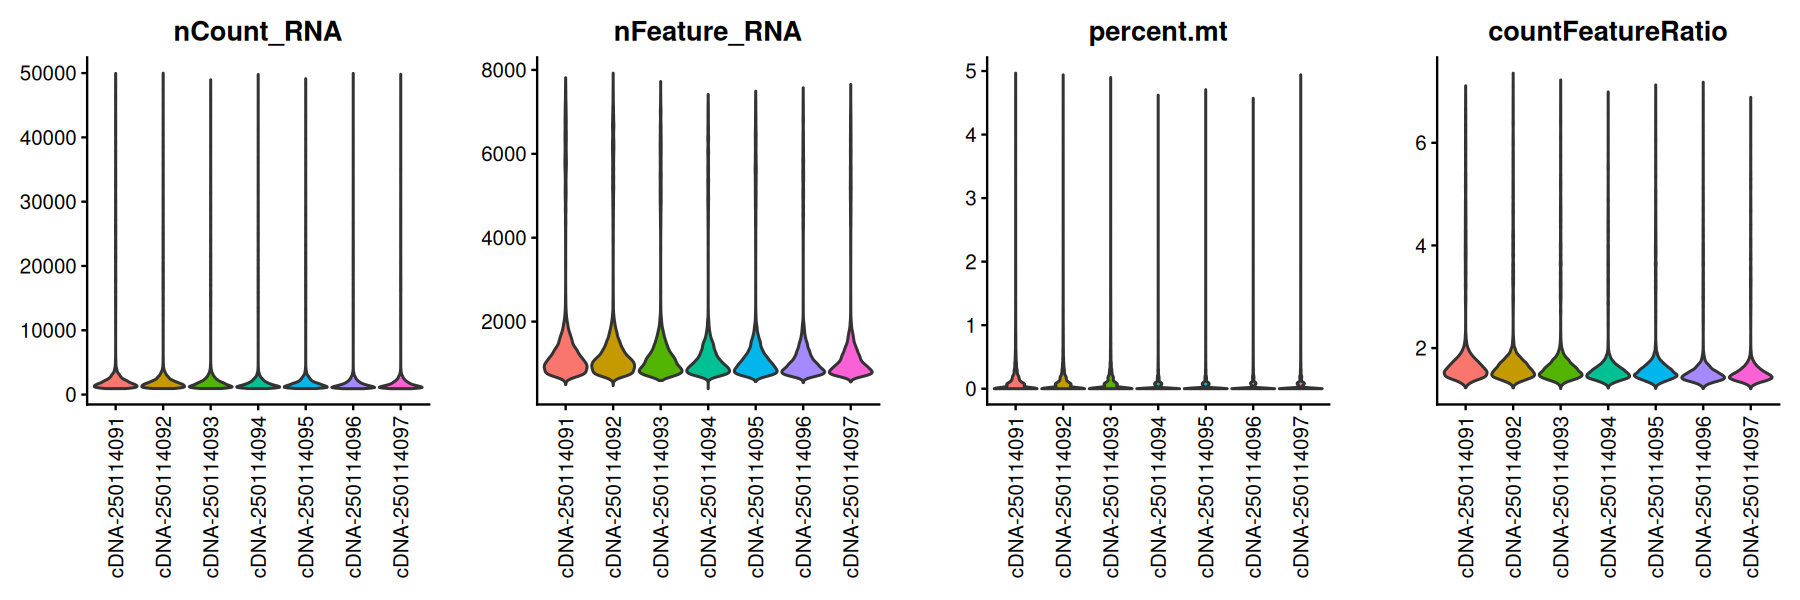

In [12]:
Idents(seurat_1) = "Library"
options(repr.plot.width=15, repr.plot.height=5)
print(plot_grid(
    plotlist = lapply(c("nCount_RNA", "nFeature_RNA", "percent.mt", "countFeatureRatio"), function(x) {
        p = VlnPlot(seurat_1, features=x, pt.size=0) + 
            theme(axis.text.x=element_text(vjust=0.5, hjust=0.5, angle=90), axis.title.x = element_blank()) +
            guides(fill=FALSE)
        return(p)
    }), 
    ncol=4, align="hv", axis="tblr"
))

In [15]:
SCTseurat = SCTransform(
    seurat_1, assay="RNA",
    ncells=ncol(seurat_1[["RNA"]]),
    variable.features.n=3000,
    vars.to.regress="percent.mt",
    return.only.var.genes = T,
    method="glmGamPoi"
)

Running SCTransform on assay: RNA

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 19059 by 65945

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 65945 cells

Found 63 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 19059 genes

Computing corrected count matrix for 19059 genes

Calculating gene attributes

Wall clock passed: Time difference of 5.251885 mins

Determine variable features

Regressing out percent.mt

Centering data matrix

Place corrected count matrix in counts slot

Set default assay to SCT



In [16]:
SCTseurat = SCTseurat %>%
    RunPCA(npcs=100, verbose = FALSE) %>%
    FindNeighbors(dims = 1:30) %>%
    FindClusters(verbose = FALSE, resolution = 0.7, random.seed = 111) %>%
    RunUMAP(dims = 1:30,umap.method = "umap-learn")

Computing nearest neighbor graph



Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


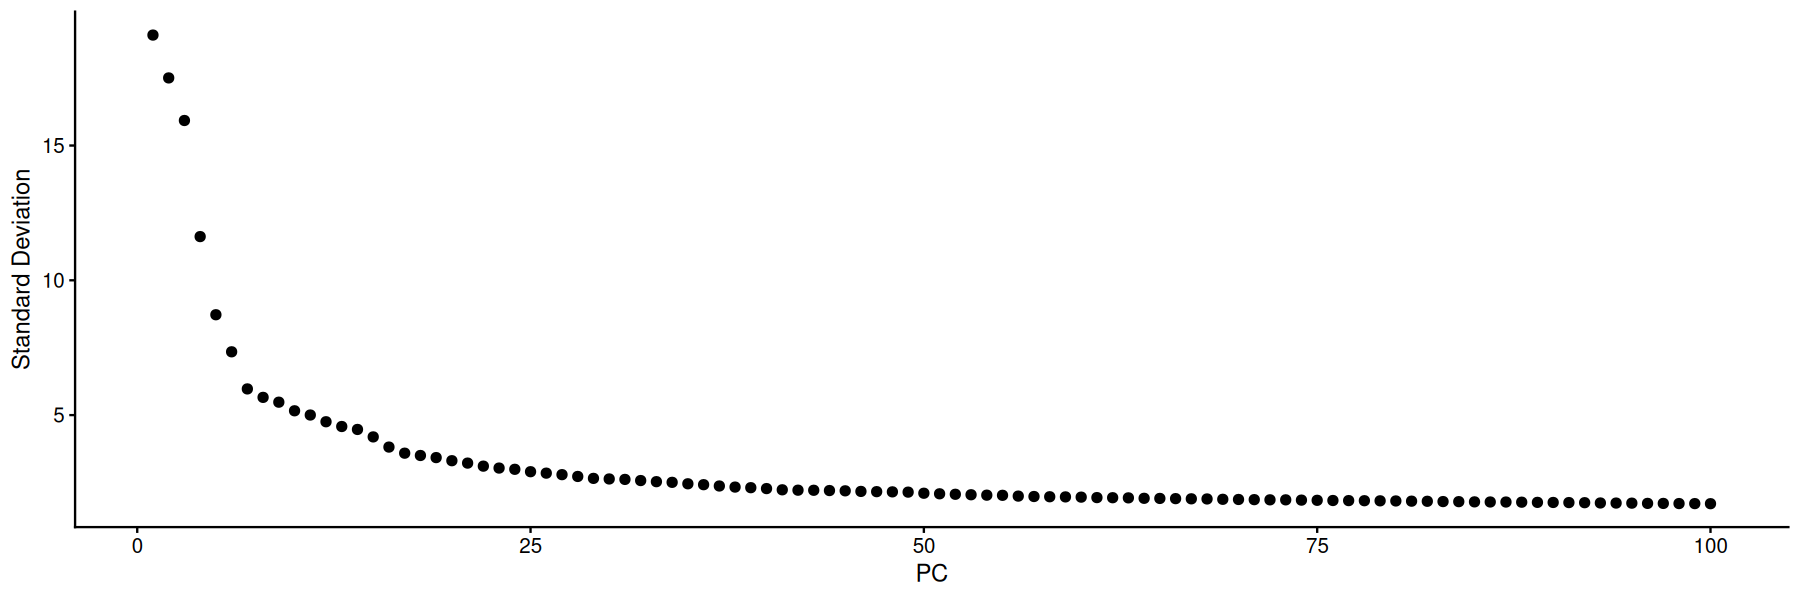

In [17]:
plot <- ElbowPlot(SCTseurat,ndims =100 , reduction = 'pca')
plot

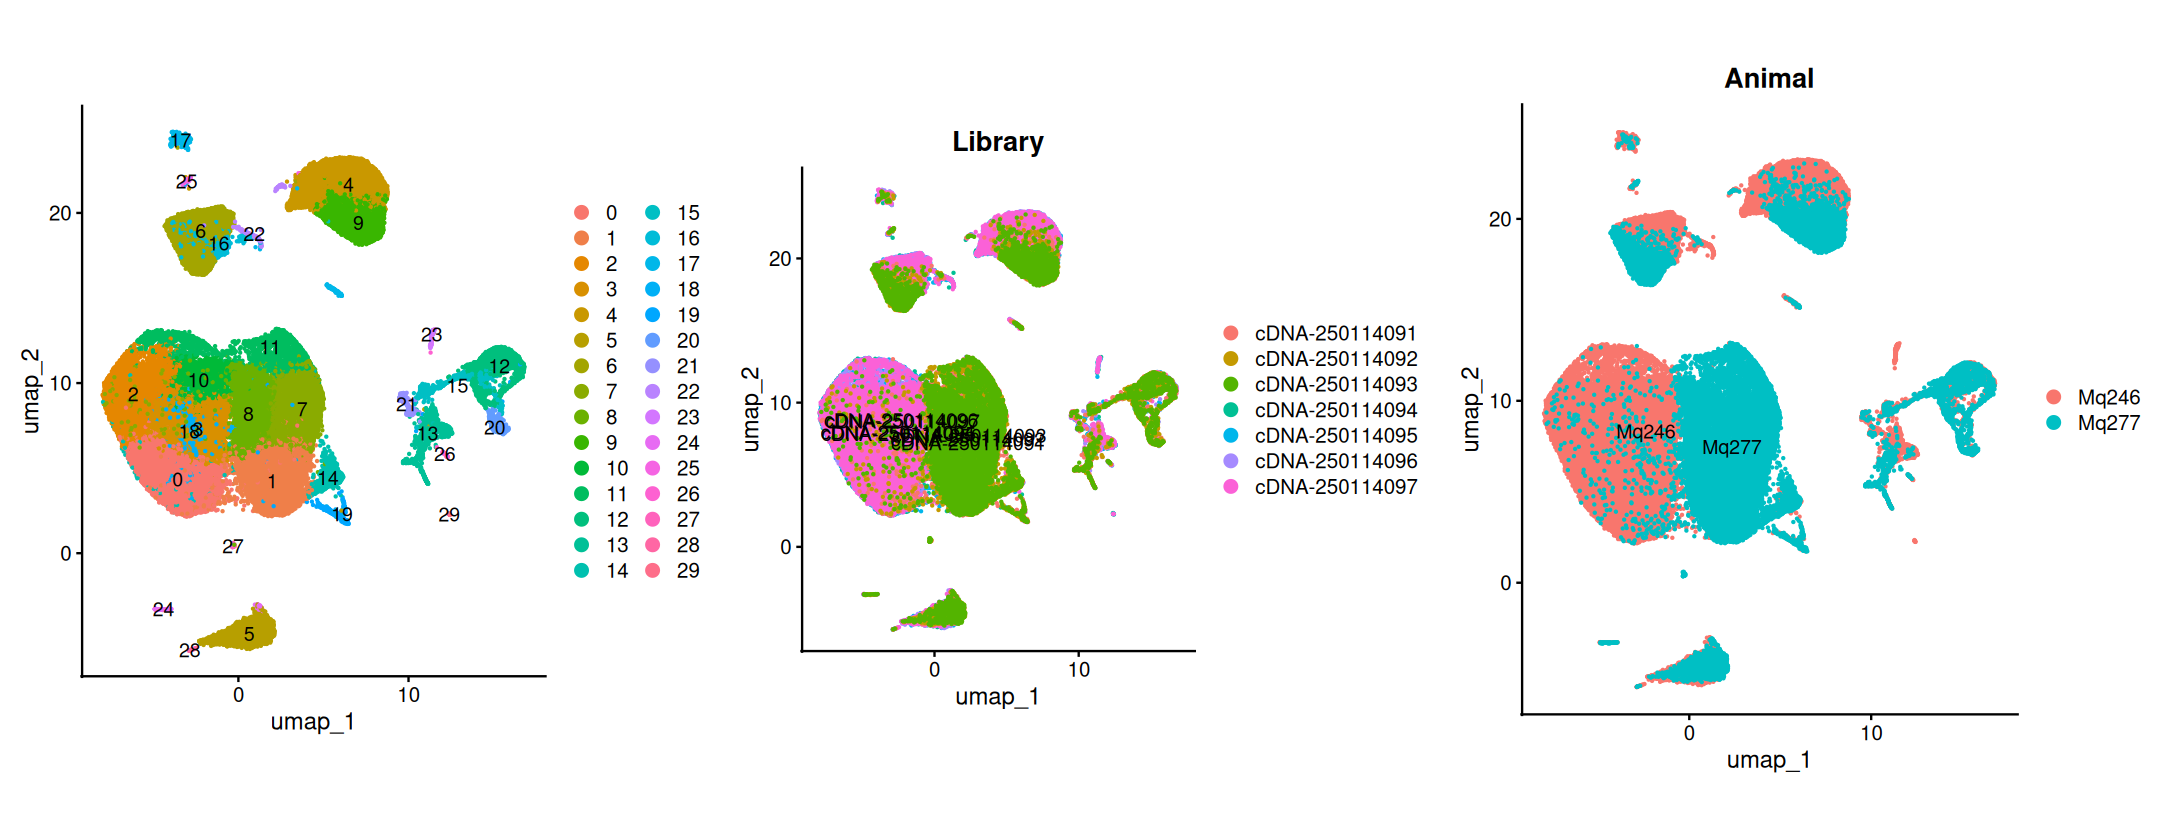

In [18]:
options(repr.plot.width=18, repr.plot.height=7)
plot_grid(
    DimPlot(SCTseurat, reduction="umap", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat, reduction="umap", group.by="Library", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

In [19]:
# 去批次
SCTseurat_harmony = SCTseurat %>%
    RunHarmony(group.by.vars = c("Animal"),dims.use = 1:25 ,theta = 2,reduction = "pca", max.iter.harmony = 10,sigma = 0.1,assay.use = "SCT", reduction.save = "harmony") %>%
    FindNeighbors(dims = 1:25, reduction = "harmony") %>%
    FindClusters(verbose = FALSE, resolution =0.5, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, reduction = "harmony", assay = "SCT")

Warning message:
“Warning: The parameter max.iter.harmony is replaced with parameter max_iter. It will be ignored for this function call and please use parameter max_iter in future function calls.
This warning is displayed once per session.”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Warning message:
“The default method for RunU

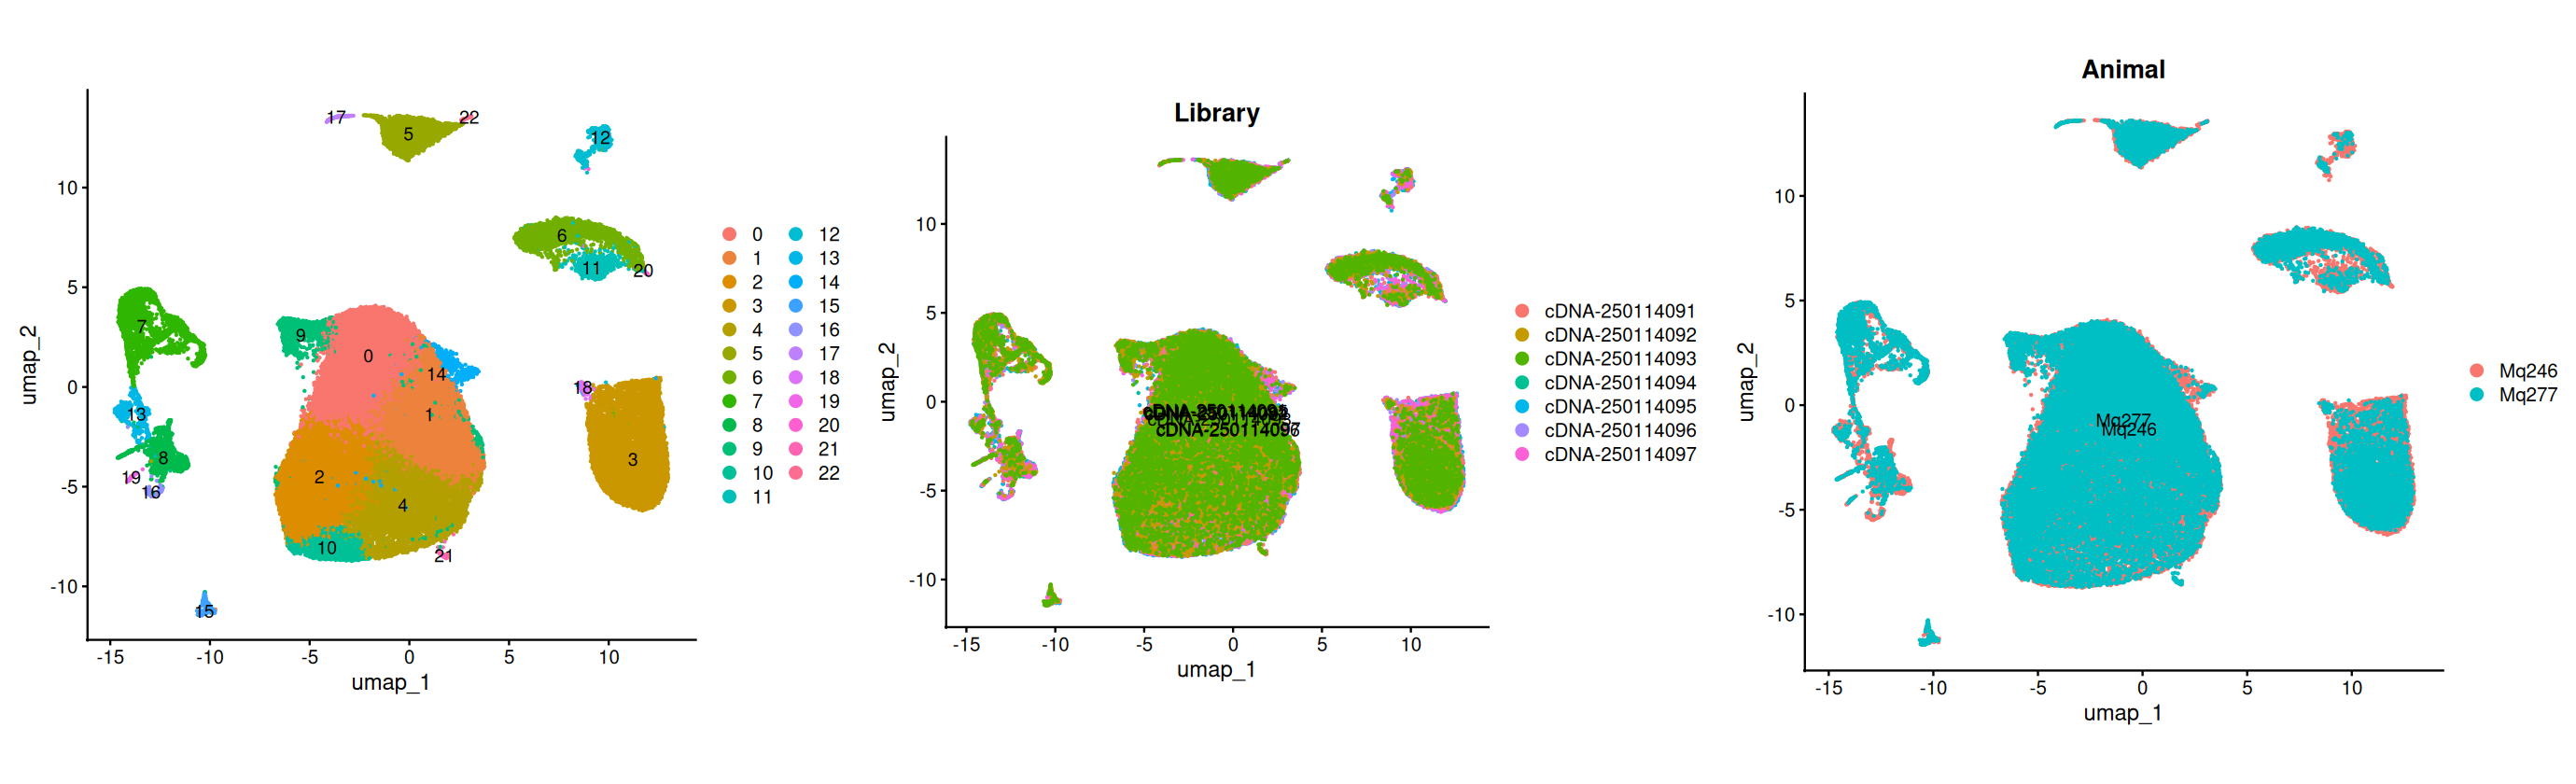

In [20]:
options(repr.plot.width=23, repr.plot.height=7)
plot_grid(
    DimPlot(SCTseurat_harmony, reduction="umap", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony, reduction="umap", group.by="Library", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

In [21]:
df1 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/IP-VTA_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)
df2 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/VTA_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)
df1 %>% head()
df2 %>% head()


,class_label,class_name,class_bootstrapping_probability,subclass_label,subclass_name,subclass_bootstrapping_probability,supertype_label,supertype_name,supertype_bootstrapping_probability,cluster_label,cluster_name,cluster_alias,cluster_bootstrapping_probability
,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>
cDNA-250114091:CELL2_N2,CS20230722_CLAS_21,21 MB Dopa,0.84,CS20230722_SUBC_215,215 SNc-VTA-RAmb Foxa1 Dopa,1.00,CS20230722_SUPT_0886,0886 SNc-VTA-RAmb Foxa1 Dopa_7,0.25,CS20230722_CLUS_3875,3875 SNc-VTA-RAmb Foxa1 Dopa_7,2384,0.25
cDNA-250114091:CELL3_N3,CS20230722_CLAS_30,30 Astro-Epen,1.00,CS20230722_SUBC_318,318 Astro-NT NN,0.93,CS20230722_SUPT_1160,1160 Astro-NT NN_2,0.93,CS20230722_CLUS_5214,5214 Astro-NT NN_2,14956,0.92
cDNA-250114091:CELL4_N2,CS20230722_CLAS_31,31 OPC-Oligo,0.99,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.92
cDNA-250114091:CELL5_N2,CS20230722_CLAS_31,31 OPC-Oligo,0.97,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.99
cDNA-250114091:CELL6_N2,CS20230722_CLAS_21,21 MB Dopa,0.96,CS20230722_SUBC_215,215 SNc-VTA-RAmb Foxa1 Dopa,1.00,CS20230722_SUPT_0881,0881 SNc-VTA-RAmb Foxa1 Dopa_2,0.40,CS20230722_CLUS_3848,3848 SNc-VTA-RAmb Foxa1 Dopa_2,2389,0.35
cDNA-250114091:CELL10_N1,CS20230722_CLAS_31,31 OPC-Oligo,0.95,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,1.00


,class_label,class_name,class_bootstrapping_probability,subclass_label,subclass_name,subclass_bootstrapping_probability,supertype_label,supertype_name,supertype_bootstrapping_probability,cluster_label,cluster_name,cluster_alias,cluster_bootstrapping_probability
,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>
cDNA-250114094:CELL1_N5,CS20230722_CLAS_31,31 OPC-Oligo,0.78,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,1.00
cDNA-250114094:CELL2_N4,CS20230722_CLAS_30,30 Astro-Epen,0.46,CS20230722_SUBC_321,321 Astroependymal NN,0.45,CS20230722_SUPT_1169,1169 Astroependymal NN_1,0.49,CS20230722_CLUS_5237,5237 Astroependymal NN_1,14865,0.49
cDNA-250114094:CELL3_N2,CS20230722_CLAS_20,20 MB GABA,0.96,CS20230722_SUBC_202,202 PRT Tcf7l2 Gaba,0.79,CS20230722_SUPT_0829,0829 PRT Tcf7l2 Gaba_1,0.84,CS20230722_CLUS_3606,3606 PRT Tcf7l2 Gaba_1,3427,0.69
cDNA-250114094:CELL5_N4,CS20230722_CLAS_31,31 OPC-Oligo,1.00,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,1.00
cDNA-250114094:CELL7_N5,CS20230722_CLAS_31,31 OPC-Oligo,0.96,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,0.96,CS20230722_CLUS_5288,5288 MOL NN_4,5237,0.40
cDNA-250114094:CELL8_N5,CS20230722_CLAS_30,30 Astro-Epen,1.00,CS20230722_SUBC_318,318 Astro-NT NN,0.88,CS20230722_SUPT_1160,1160 Astro-NT NN_2,0.97,CS20230722_CLUS_5214,5214 Astro-NT NN_2,14956,0.94


In [36]:
saveRDS(SCTseurat_harmony, "/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/VTA_SCTseurat_harmony.rds")

In [22]:
SCTseurat_harmony_2 = SCTseurat_harmony

# 按照 index (细胞名/行名) 顺序添加
mouse_anno = c(df1$class_name, df2$class_name)
names(mouse_anno) = c(rownames(df1), rownames(df2))
# 只添加有 index 匹配的，用对象的 cell 名做索引
matched_anno = mouse_anno[colnames(SCTseurat_harmony_2)]
SCTseurat_harmony_2$Mouse_anno = matched_anno

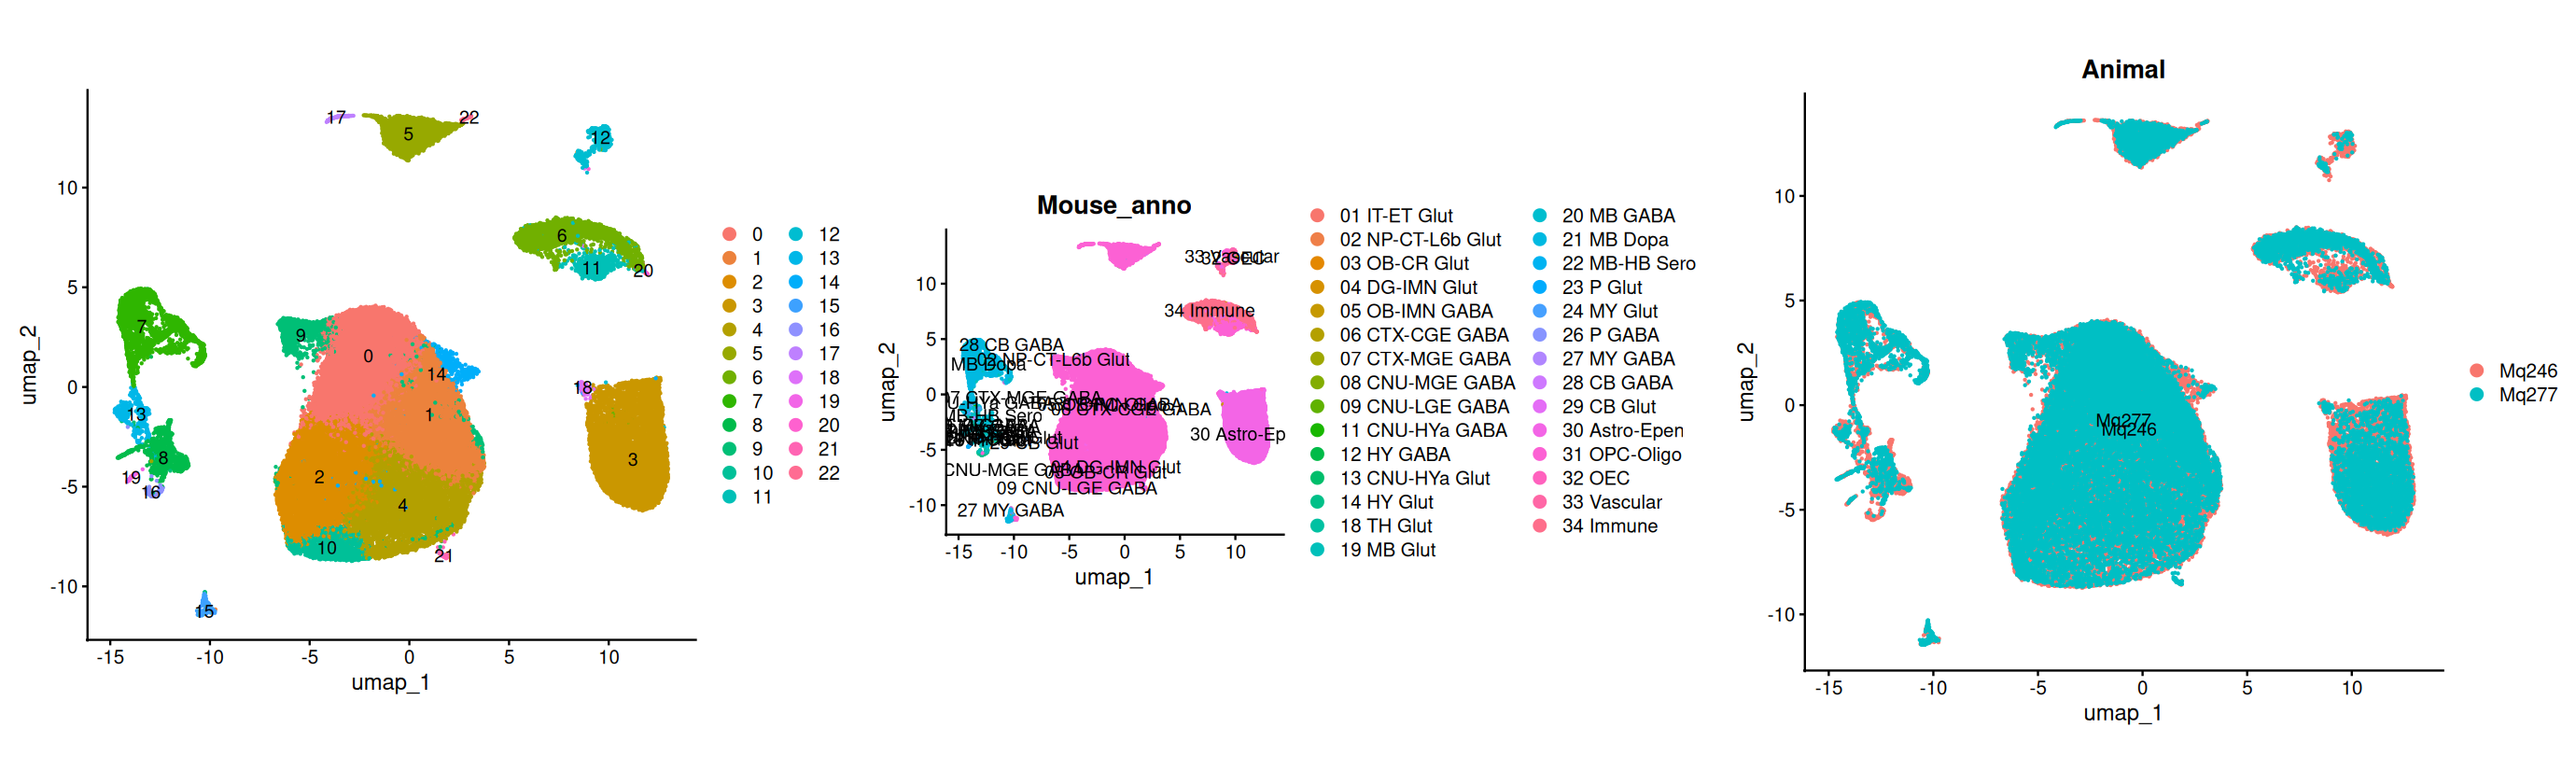

In [23]:
options(repr.plot.width=23, repr.plot.height=7)
plot_grid(
    DimPlot(SCTseurat_harmony_2, reduction="umap", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony_2, reduction="umap", group.by="Mouse_anno", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony_2, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

In [17]:
table(SCTseurat_harmony_2$Mouse_anno, SCTseurat_harmony_2$seurat_clusters)

                   
                        0     1     2     3     4     5     6     7     8     9
  01 IT-ET Glut         0     0     0     1     1     0   108     0     2     0
  02 NP-CT-L6b Glut     0     0     0     0     0     0     5     0     0     0
  03 OB-CR Glut         0     0     2     0     0     0     4     1     1     0
  04 DG-IMN Glut        1     0     1     2     0     0     1     0     1     1
  05 OB-IMN GABA        3     1     7     4     1     1    14     3     5     2
  06 CTX-CGE GABA       1     1     0     2     0     1    25     1     1     0
  07 CTX-MGE GABA       0     0     0     0     0     0    29     0     0     0
  08 CNU-MGE GABA       0     0     0     0     0     0    26     0     0     0
  09 CNU-LGE GABA       0     0     0     0     0     1     6     0     0     0
  10 LSX GABA           0     0     0     0     0     0     0     0     0     0
  11 CNU-HYa GABA       1     0     0     2     2     0    66     0     2     0
  12 HY GABA        

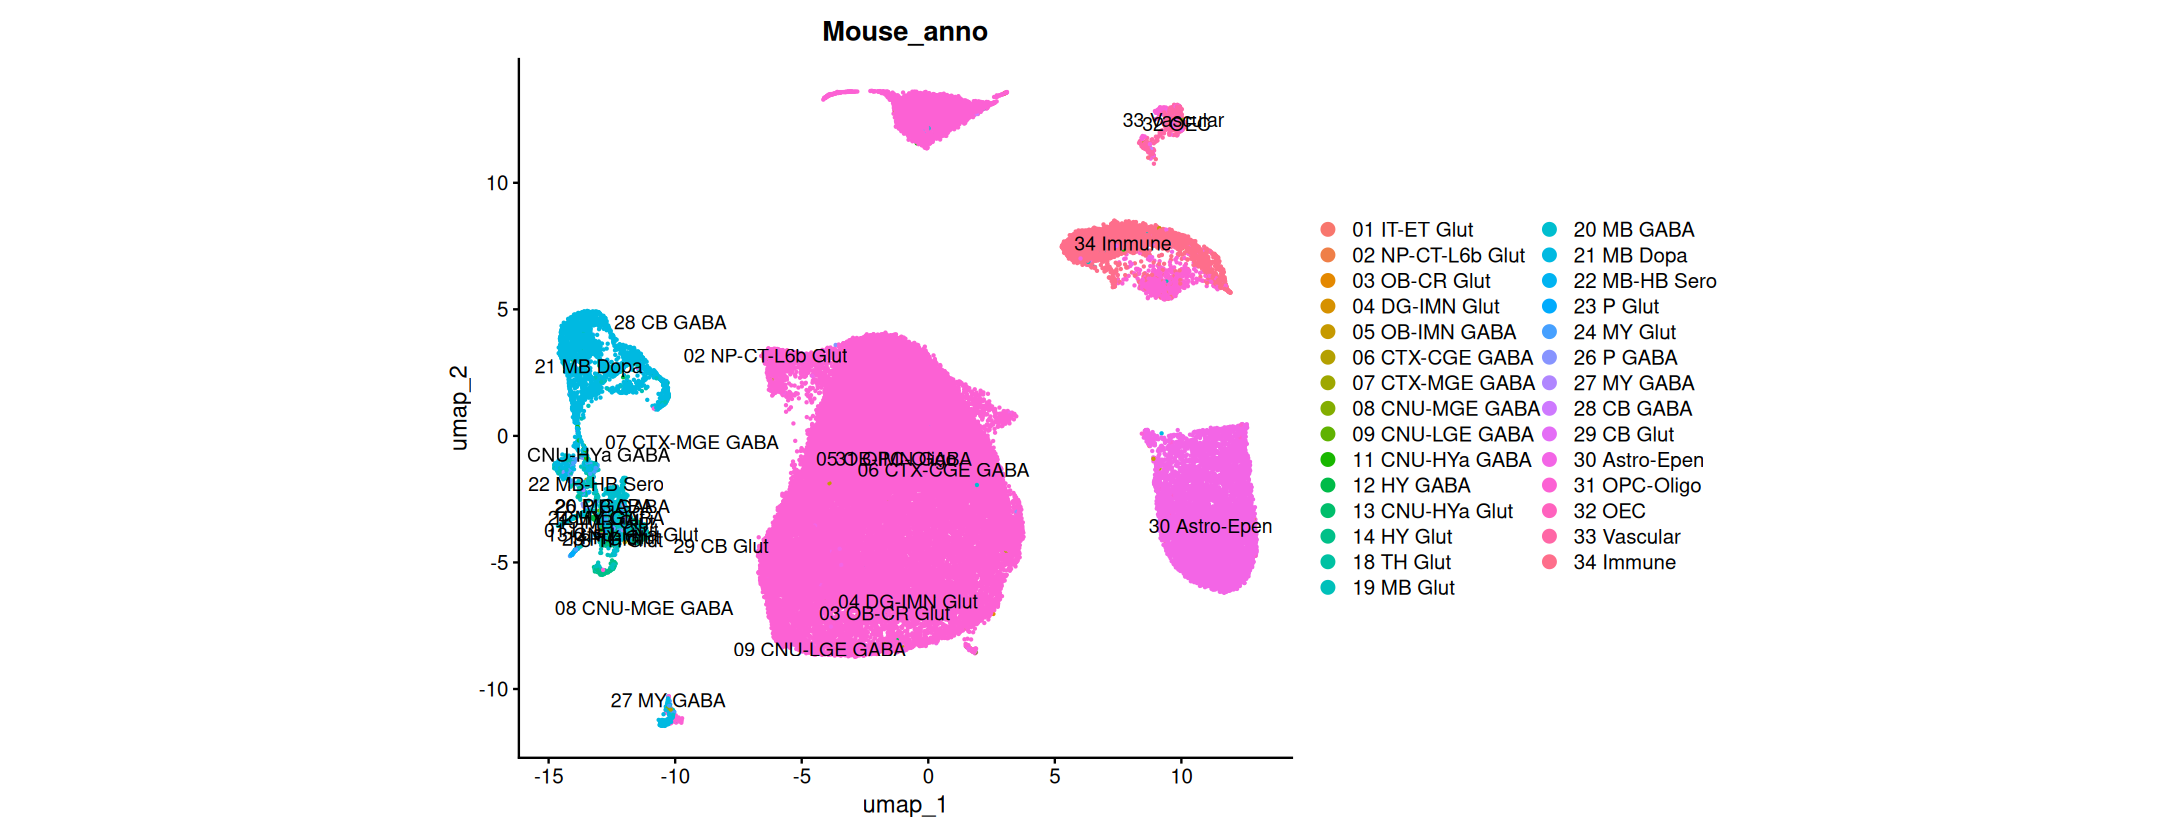

In [24]:
options(repr.plot.width=18, repr.plot.height=7)
DimPlot(SCTseurat_harmony_2, reduction="umap", group.by="Mouse_anno", label=T,raster=FALSE)+coord_fixed()

In [34]:
table(SCTseurat_harmony_2$Mouse_anno)


    01 IT-ET Glut 02 NP-CT-L6b Glut     03 OB-CR Glut    04 DG-IMN Glut 
              130                 7                10                 9 
   05 OB-IMN GABA   06 CTX-CGE GABA   07 CTX-MGE GABA   08 CNU-MGE GABA 
               76                46                36                33 
  09 CNU-LGE GABA       10 LSX GABA   11 CNU-HYa GABA        12 HY GABA 
               16                 1               151               367 
  13 CNU-HYa Glut        14 HY Glut        18 TH Glut        19 MB Glut 
               98              2409                 2              4333 
       20 MB GABA        21 MB Dopa     22 MB-HB Sero         23 P Glut 
             2172              4650                19               475 
       24 MY Glut         26 P GABA        27 MY GABA        28 CB GABA 
              652               262                40                23 
       29 CB Glut     30 Astro-Epen      31 OPC-Oligo            32 OEC 
                6             17130             58

In [24]:
Excit = c("SNAP25","SLC17A6",'NTNG1' , "RBFOX3","NEFM","NEFH","NEFL","STMN2")

Inhib = c("GAD1", "GAD2",'ADARB2',"FBXL7","KIT","TRPS1")

Astrocytes = c("SLC1A2","SLC1A3","S100B", "AQP4", "APOE",'GJA1','ALDH1L1','AGT','EDNRB' ,"GFAP")
Ependymal = c("FOXJ1", "PIFO", "DYNLRB2", "RSPH1", "DNAH12", "FAM216B", "ZMYDN10", "IQCG", "ENKUR","LRRC23" )

Endotheial = c("PECAM1","VWF","CD34","VECAD" ,"CLDN5","KDR","CD105",'FLT1','RAMP2','GNG11' )
# Pericytes = c("PDGFRB", "MCAM", "RGS5", "ALPHA-SMA", "KCNJ8",'TAGLN','COX4l2','MOTCH3','ABCC9' )
OPC = c("ABRACL", "PDGFRALPHA", "OLIG2", "CSPG4", "OLIG1", "VCAN",'LHFPL3','SOX6','GPR17','BCAN',"PTPRZ1","PDGFRA","COL9A1" )
Oligo = c("PLP1",'MOG','MOBP','CLDN11','MAG','CNP','PTGDS','GPR37','FA2H','APOD' )
Microglia = c('CD68','C1QB','OLR1','HAVCR2','C1QC','CSF3R','CS3CR1','P2RY12','SALL1','TLR2',"ITGAM")

In [25]:
Neuron = c('RBFOX3', 'SNAP25', 'SYT1')
DA= c('TH', 'DDC', 'SLC6A3', 'SLC18A2', 'DRD2', 'GCH1', 'PITX3', 'NR4A2')
VTA_SNc_DA = c('CALB1', 'ALDH1A1', 'SOX6', 'SNCG', 'VIP')
GABA= c('GAD1', 'GAD2', 'SLC32A1')
Glut= c('SLC17A6', 'SLC17A7', 'SLC17A8')
Astro= c( 'GFAP', 'SLC1A2', 'SLC1A3')
Oligo= c('MOBP', 'MBP', 'PLP1', 'MOG')
OPC= c('PDGFRA', 'CSPG4', 'OLIG1', 'OLIG2')
Microglia= c('CX3CR1', 'P2RY12', 'C3', 'AIF1', 'TYROBP')
Endothelial= c('CLDN5', 'FLT1', 'PECAM1', 'VWF')
Mural= c('PDGFRB', 'RGS5')
VLMC= c('DCN', 'LUM', 'COL1A1')
Ependymal= c('FOXJ1', 'TTR', 'TMEM212')

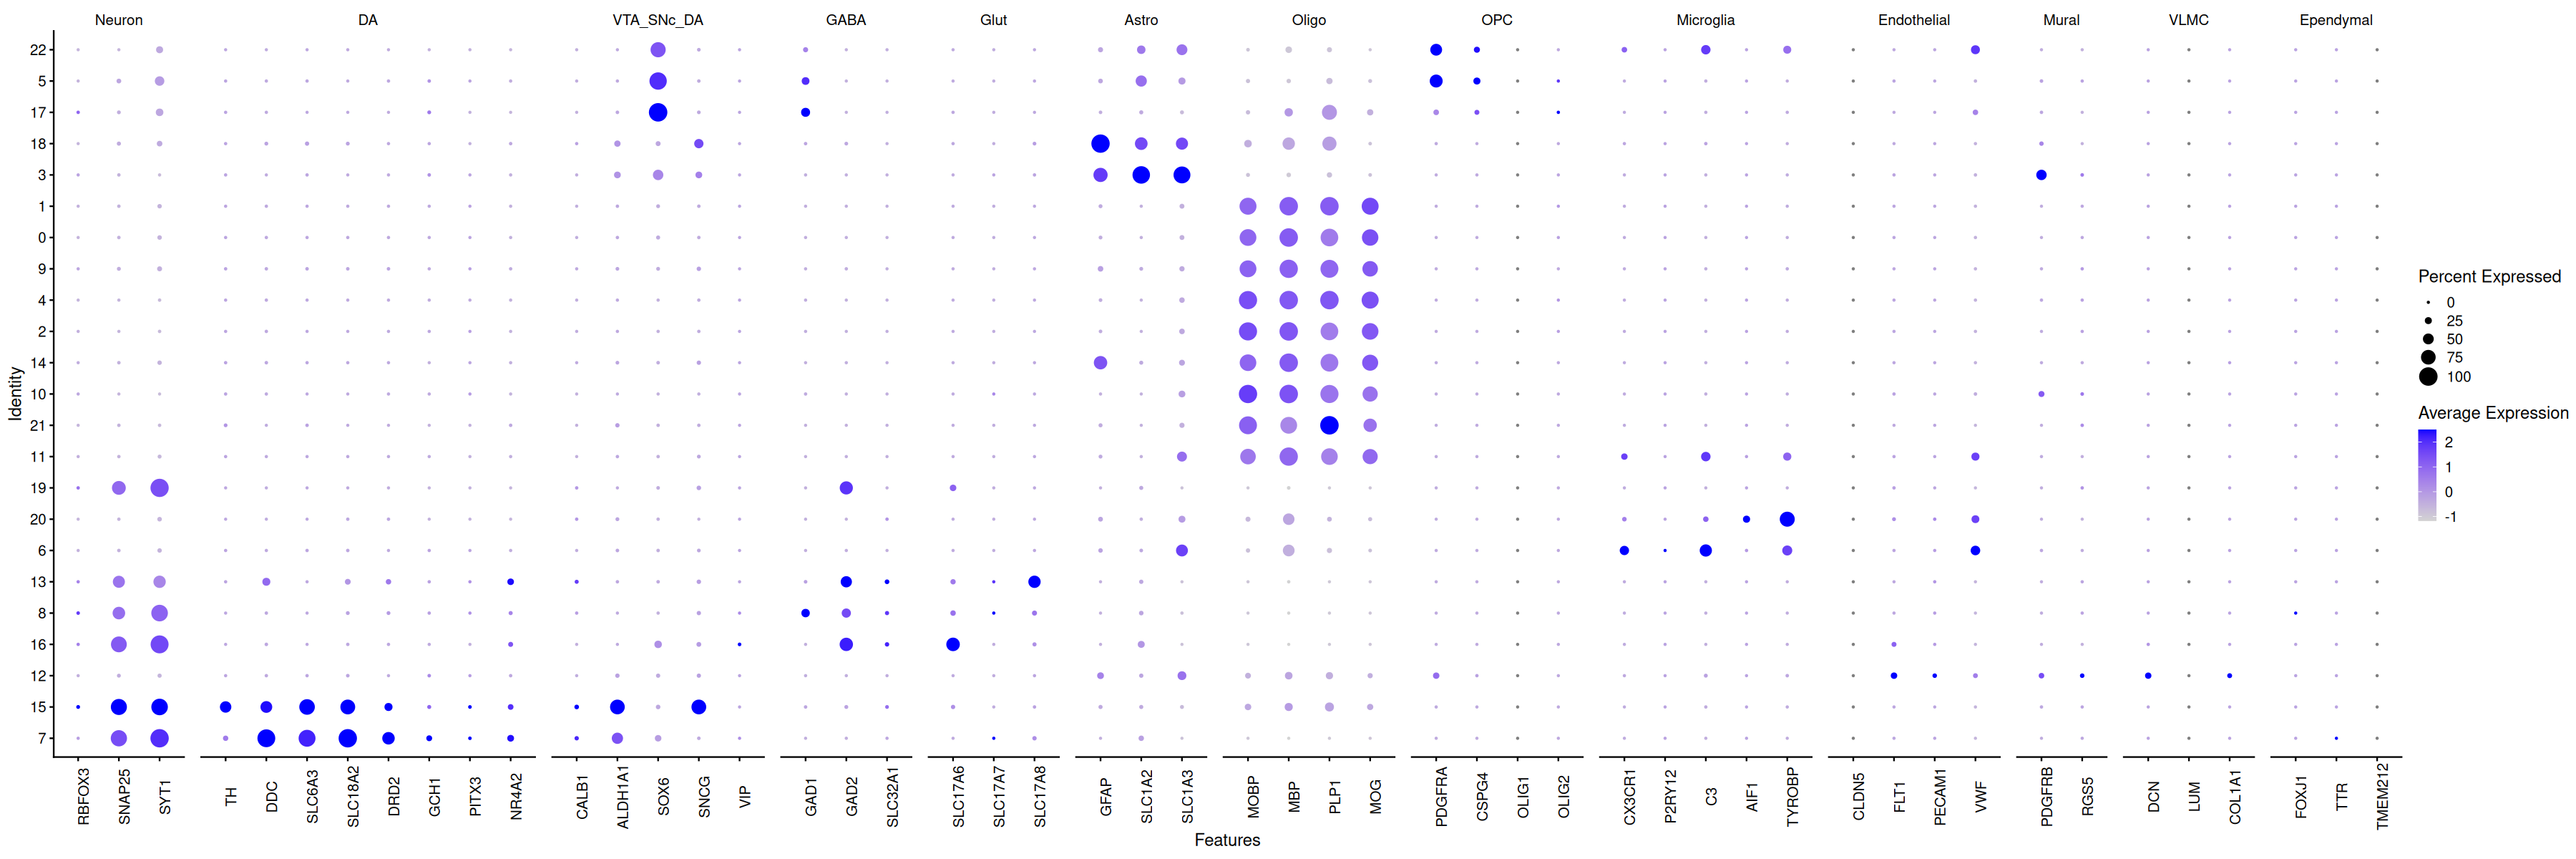

In [26]:
# selectMarkers=selectMarkers[!duplicated(selectMarkers)]
Idents(SCTseurat_harmony) = "seurat_clusters"
options(repr.plot.height=10,repr.plot.width=30)
features <- list(
"Neuron" = Neuron, 
"DA" = DA, 
"VTA_SNc_DA" = VTA_SNc_DA, 
"GABA" = GABA,  
"Glut" = Glut,
"Astro" = Astro,
"Oligo" = Oligo,
"OPC" = OPC,
"Microglia" = Microglia,
"Endothelial" = Endothelial,
"Mural" = Mural,
"VLMC" = VLMC,
"Ependymal" = Ependymal
)

features=features[!duplicated(features)]

DotPlot(SCTseurat_harmony, features = features, cluster.idents=T) + theme(axis.text.x = element_text(angle = 90))


In [28]:

SCTseurat_harmony_2@meta.data$class='Uncertain'

SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(16,8,13,19),]$class='Neuron'
# SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(6,22),]$class='Excit'
# SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(23,10,33,21,24),]$class='Inhibit'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(7,15),]$class='DA'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(3,18),]$class='Astro'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(21,10,14,2,4,9,0,1),]$class='Oligo'
# SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(),]$class='Endotheial'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(5,22,17),]$class='OPC'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(20,6,11),]$class='Microglia'
# SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(),]$class='Mural'
SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(12),]$class='VLMC/EC'
# SCTseurat_harmony_2@meta.data[SCTseurat_harmony_2@meta.data$seurat_clusters %in% c(),]$class='Ependymal'



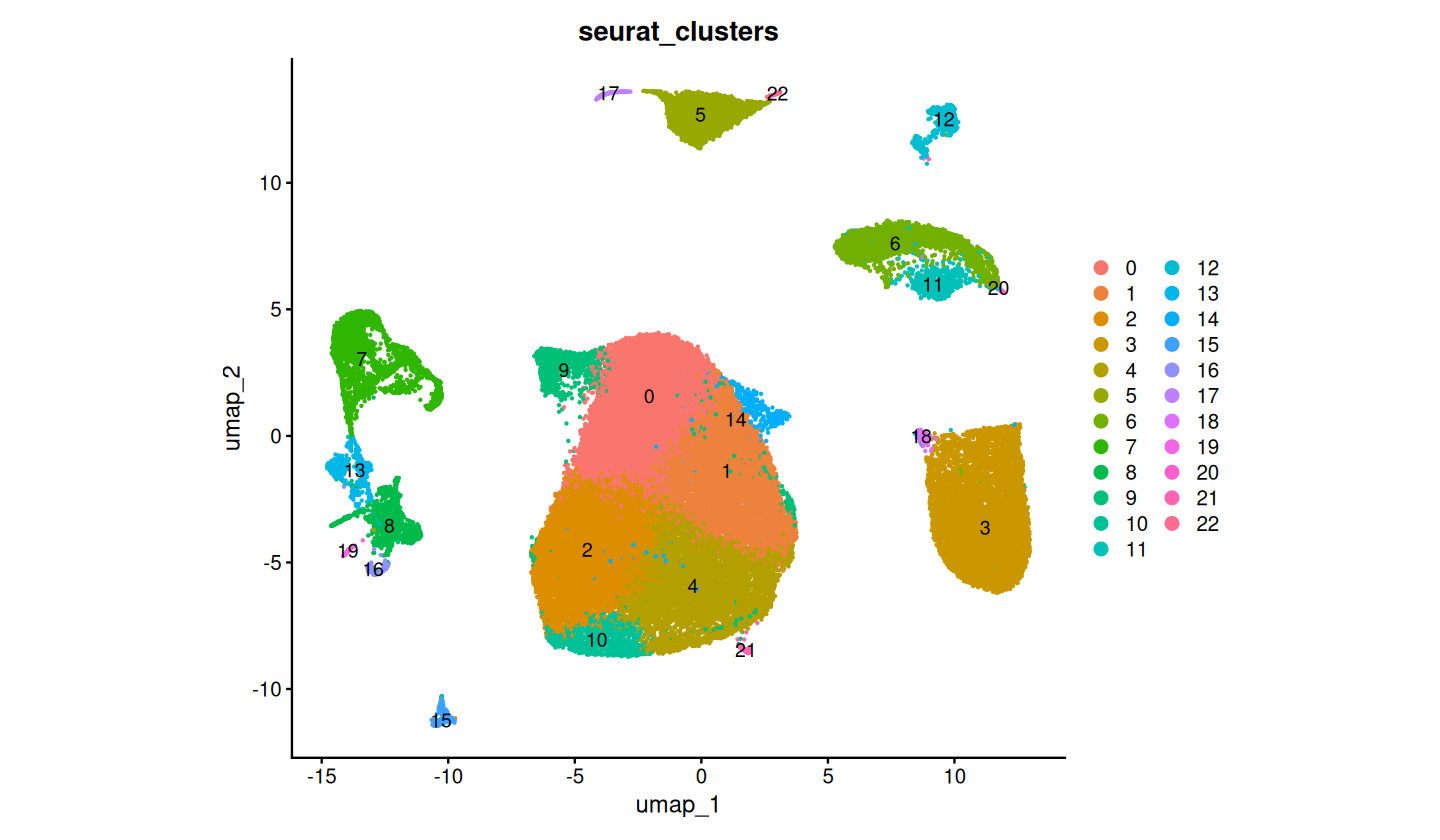

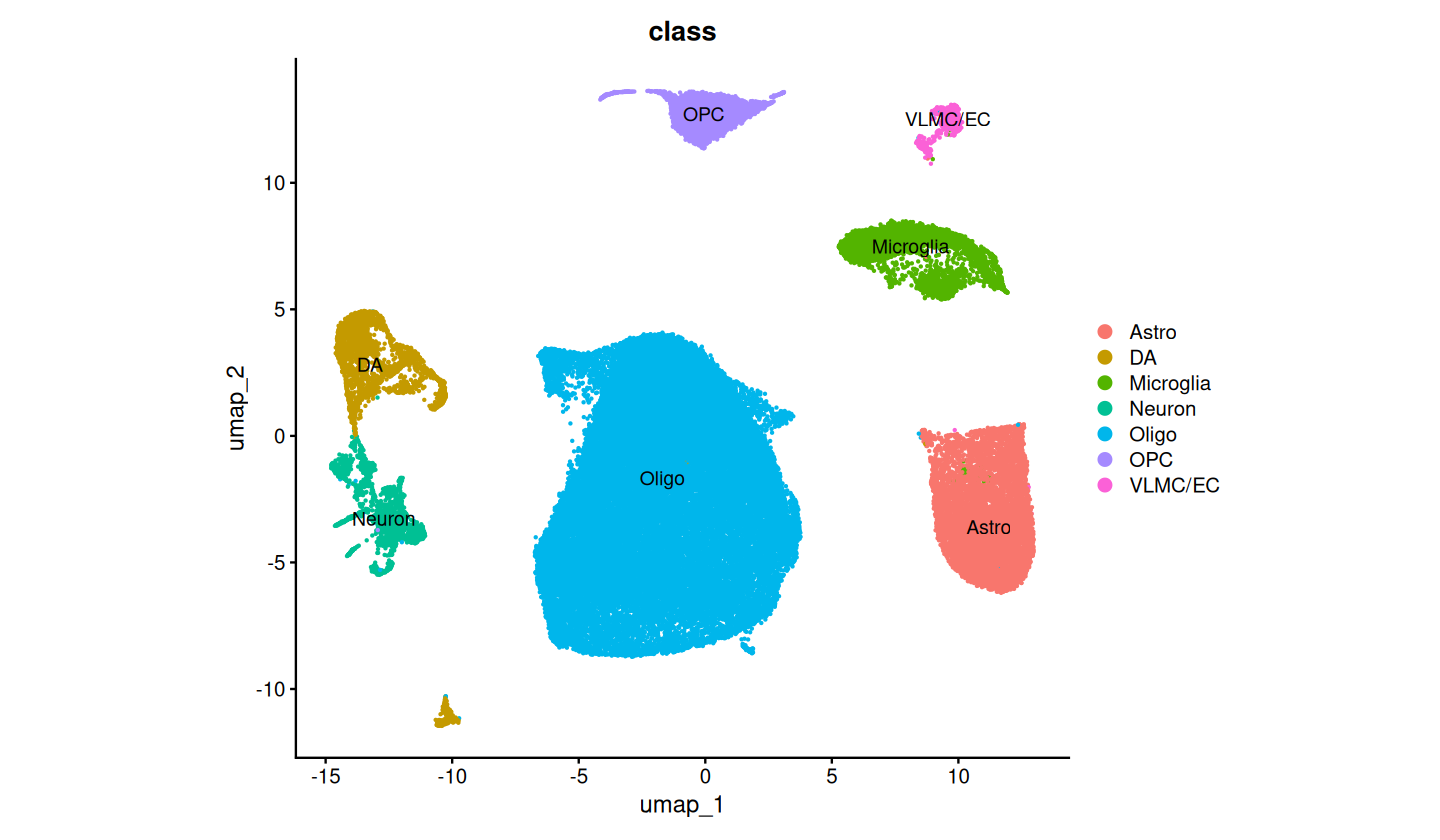

In [29]:
options(repr.plot.width=12, repr.plot.height=7)
DimPlot(SCTseurat_harmony_2, reduction="umap", group.by="seurat_clusters", label=T,raster=FALSE)+coord_fixed()
DimPlot(SCTseurat_harmony_2, reduction="umap", group.by="class", label=T,raster=FALSE)+coord_fixed()

In [30]:
sampleRatio = 0.8
maxCell = 2000
sampleDf = SCTseurat_harmony_2@meta.data[, c("class"), drop=F]
sampleList = split(sampleDf, sampleDf$class)
sampleList = lapply(sampleList, function(x) {
    sampleSize = as.integer(nrow(x)*0.8)
    if (sampleSize > maxCell) {
        sampleSize = maxCell
    }
    sampleIdx = 1:nrow(x)
    sampleIdx = sample(1:nrow(x), size=sampleSize, replace=F)
    return(x[sampleIdx,,drop=F])
})
sampleDf = Reduce(rbind, sampleList)
str(sampleDf)
table(sampleDf$class)

'data.frame':	12525 obs. of  1 variable:
 $ class: chr  "Astro" "Astro" "Astro" "Astro" ...



    Astro        DA Microglia    Neuron     Oligo       OPC   VLMC/EC 
     2000      2000      2000      1933      2000      2000       592 

In [31]:
trainSeurat = SCTseurat_harmony_2[,rownames(sampleDf)]
table(trainSeurat$class)


    Astro        DA Microglia    Neuron     Oligo       OPC   VLMC/EC 
     2000      2000      2000      1933      2000      2000       592 

Calculating cluster Astro

Calculating cluster Neuron

Calculating cluster Oligo

Calculating cluster OPC

Calculating cluster Microglia

Calculating cluster DA

Calculating cluster VLMC/EC




    Astro    Neuron     Oligo       OPC Microglia        DA   VLMC/EC 
     2895      1287      1134       987      1351       911       835 

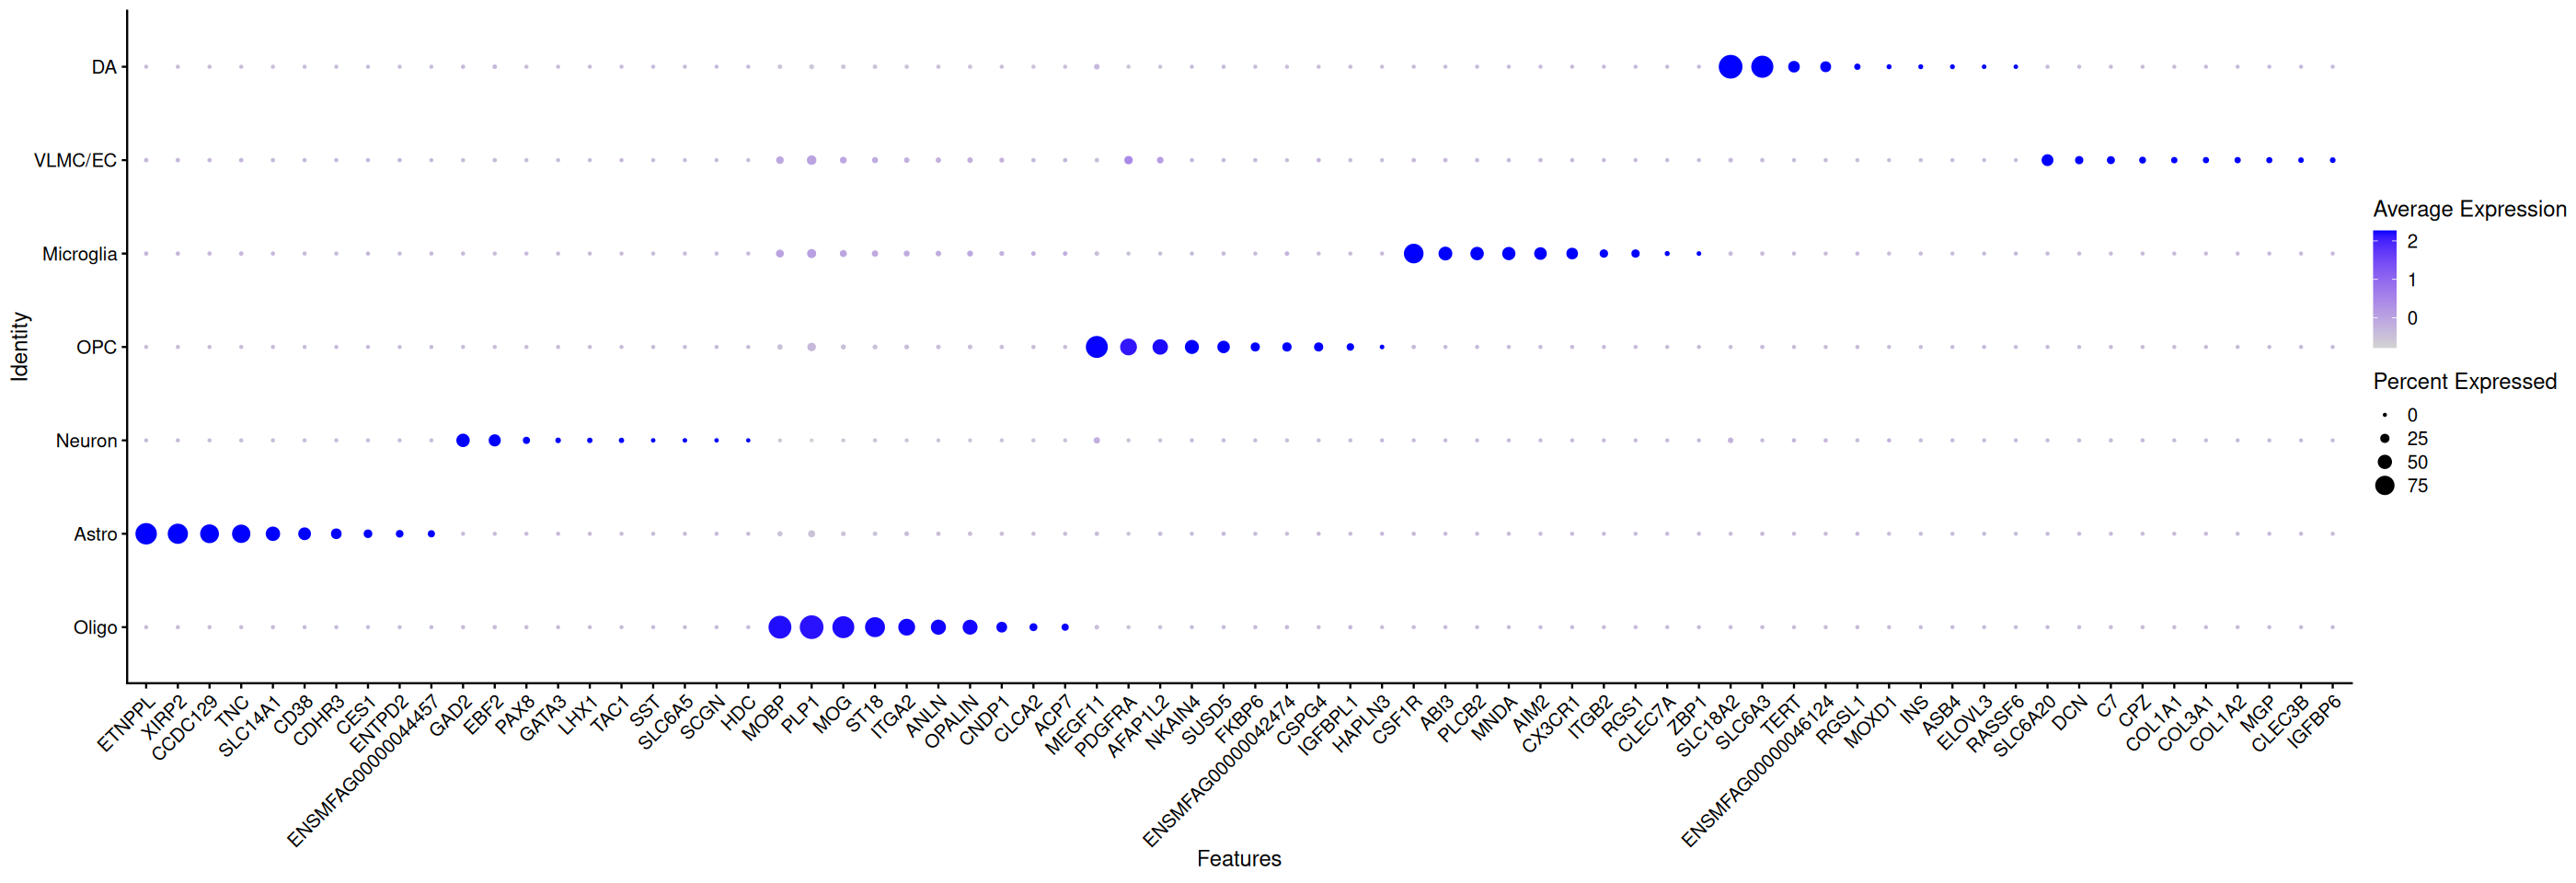

In [32]:
Idents(trainSeurat) = "class"
classMarker = FindAllMarkers(trainSeurat)
classMarker = subset(classMarker, p_val_adj < 0.01 & avg_log2FC > 1.0)
table(classMarker$cluster)

classMarkerTop = classMarker %>% group_by(cluster) %>% top_n(n = 10, wt = avg_log2FC)
options(repr.plot.width=length(unique(classMarkerTop$gene))/3, repr.plot.height=8)
Idents(SCTseurat_harmony_2) = "class"
DotPlot(SCTseurat_harmony_2, features=unique(c(classMarkerTop$gene))) + RotatedAxis()

In [33]:
trainDf = as.data.frame(t(as.matrix(trainSeurat[["SCT"]]@data[unique(classMarker$gene), ])))
trainDf$class = trainSeurat$class
trainDf = subset(trainDf, class != "Uncertain")
trainDf$class = factor(trainDf$class)
# We need to modify the name of the columns
colnames(trainDf) = paste0("col_", colnames(trainDf))
colnames(trainDf) = gsub("-", "_", colnames(trainDf))
colnames(trainDf) = gsub(" ", "_", colnames(trainDf))

rf = randomForest(col_class~., data=trainDf, ntree=500)

 num [1:7, 1:8] 1999 0 17 0 1 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:7] "Astro" "DA" "Microglia" "Neuron" ...
  ..$ : chr [1:8] "Astro" "DA" "Microglia" "Neuron" ...


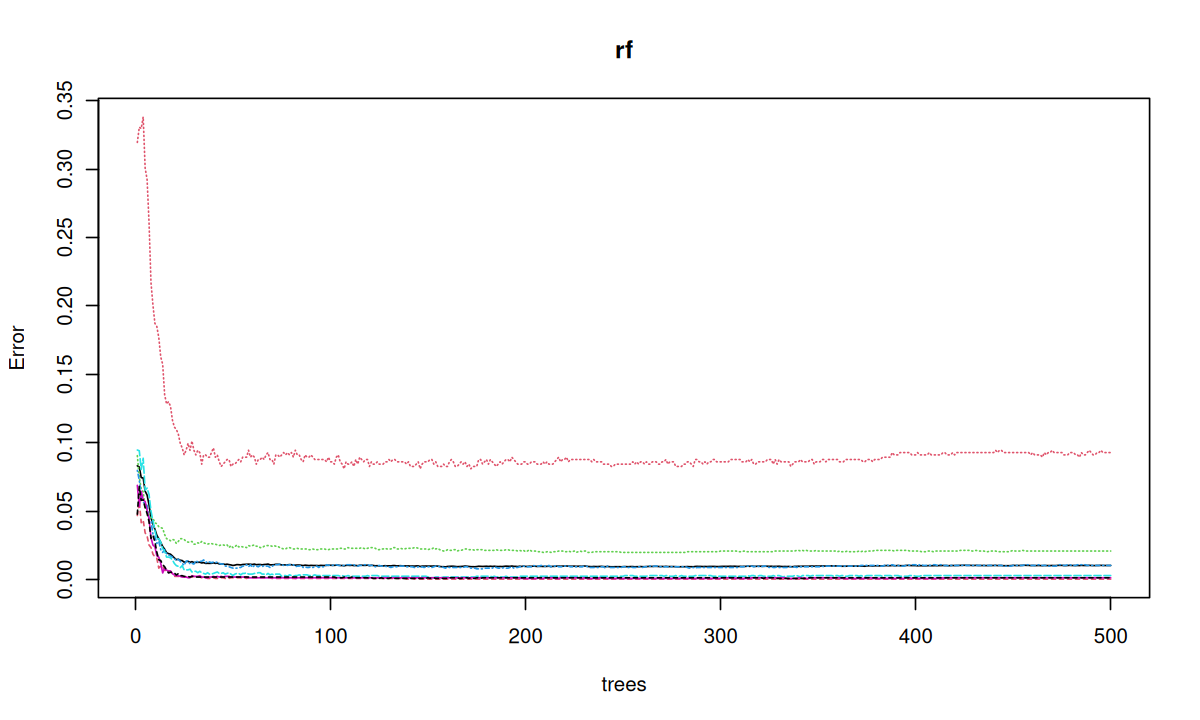

In [34]:
str(rf$confusion)
options(repr.plot.width=10, repr.plot.height=6)
plot(rf)


In [35]:
confusionRatio = t(apply(rf$confusion[1:7, 1:7], 1, function(x) {x/sum(x)}))


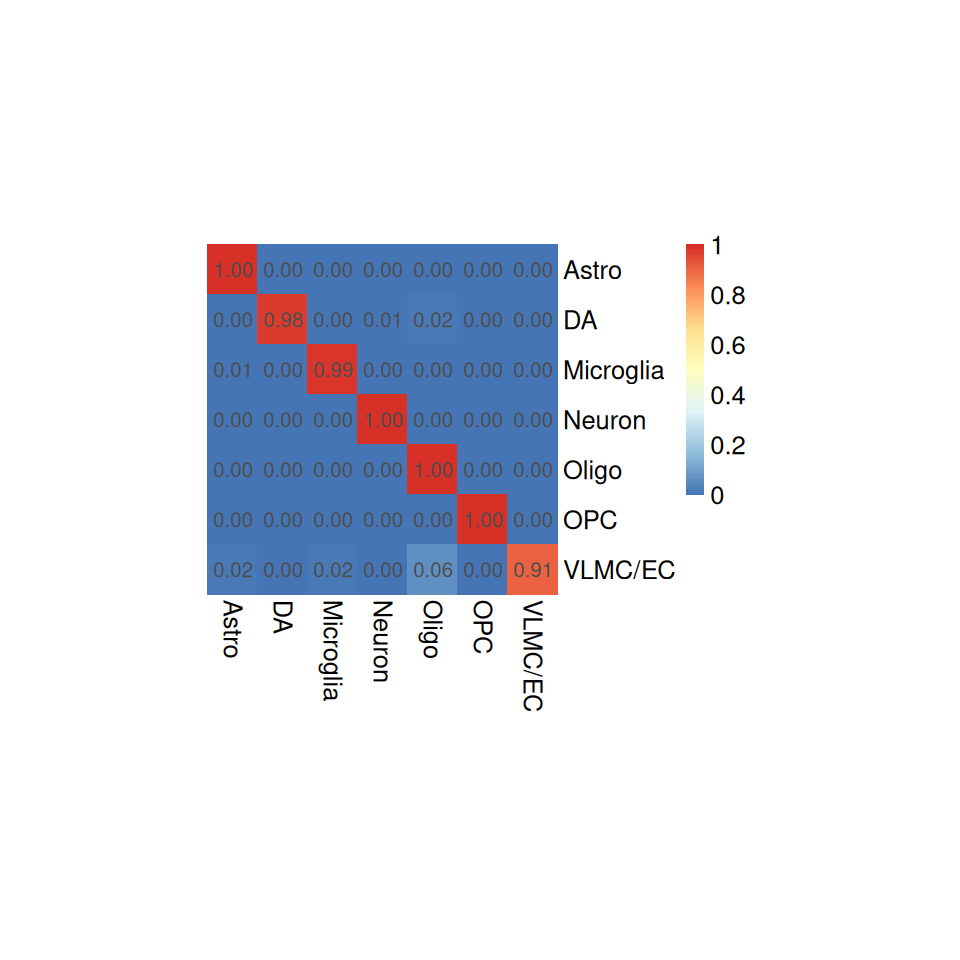

In [41]:
options(repr.plot.width=8, repr.plot.height=8)
pheatmap(confusionRatio, breaks=seq(0,1,0.01), cluster_rows=F, cluster_cols=F, border_color=NA, cellwidth=30, cellheight=30, fontsize=15, display_numbers=TRUE)

In [45]:
seuratCountDf = as.data.frame(t(as.matrix(SCTseurat_harmony_2[["SCT"]]@data[unique(classMarker$gene), ])))

colnames(seuratCountDf) = paste0("col_", colnames(seuratCountDf))
colnames(seuratCountDf) = gsub("-", "_", colnames(seuratCountDf))
seuratClassPred = predict(rf, seuratCountDf, type="prob")
str(seuratClassPred)


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 5.6 GiB”


 'matrix' num [1:98760, 1:8] 0.024 0.03 0.002 0.014 0.004 0.99 0.13 0.006 0.946 0.026 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:98760] "cDNA-250114094:CELL1_N5" "cDNA-250114094:CELL2_N4" "cDNA-250114094:CELL3_N2" "cDNA-250114094:CELL5_N4" ...
  ..$ : chr [1:8] "Astro" "DA" "Endotheial" "Microglia" ...


In [ ]:
seuratClassPredTb = tibble(
    cellId = rownames(seuratClassPred),
    maxPredClassScore = apply(seuratClassPred, 1, max),
    maxPredClass = apply(seuratClassPred, 1, function(x) {names(x)[which.max(x)]})
)
head(seuratClassPredTb)

summary(seuratClassPredTb$maxPredClassScore)
options(repr.plot.width=6, repr.plot.height=4)
plot(density(seuratClassPredTb$maxPredClassScore, adjust=0.1))

identical(seuratClassPredTb$cellId, rownames(SCTseurat_harmony_2@meta.data))
tmpDf = as.data.frame(seuratClassPredTb[c("maxPredClassScore", "maxPredClass")])
rownames(tmpDf) = seuratClassPredTb$cellId

SCTseurat_harmony_2 = AddMetaData(SCTseurat_harmony_2, tmpDf)

options(repr.plot.width=9, repr.plot.height=7)
FeaturePlot(SCTseurat_harmony_2, reduction="umap", features="maxPredClassScore",raster=FALSE)+coord_fixed()


In [47]:
Idents(SCTseurat_harmony_2) = "seurat_clusters"
cellNum0 = ncol(SCTseurat_harmony_2)
classFiltSeurat = subset(SCTseurat_harmony_2, maxPredClassScore >= 0.8)
cellNum1 = ncol(classFiltSeurat)
message("Filt cell ratio: ", cellNum1/cellNum0)


Filt cell ratio: 0.870301741595788



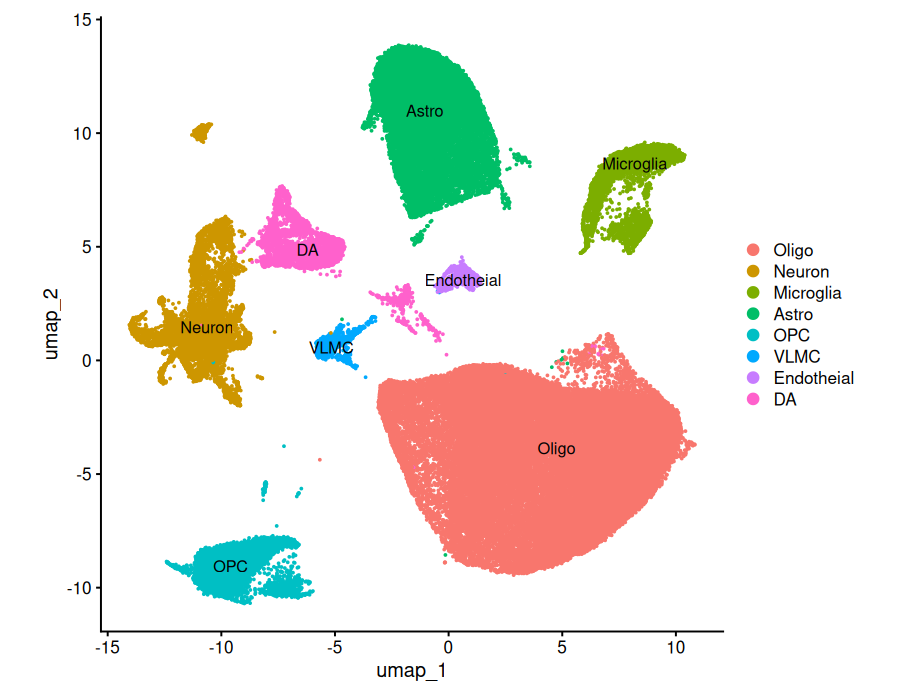

In [62]:
Idents(classFiltSeurat) = "maxPredClass"
options(repr.plot.width=9, repr.plot.height=7)
DimPlot(classFiltSeurat, reduction="umap", label=T,raster=FALSE)+coord_fixed()

In [65]:
classFiltSeurat
cleanUp_nc

An object of class Seurat 
39808 features across 85951 samples within 2 assays 
Active assay: SCT (19451 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

An object of class Seurat 
39808 features across 85863 samples within 2 assays 
Active assay: SCT (19451 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

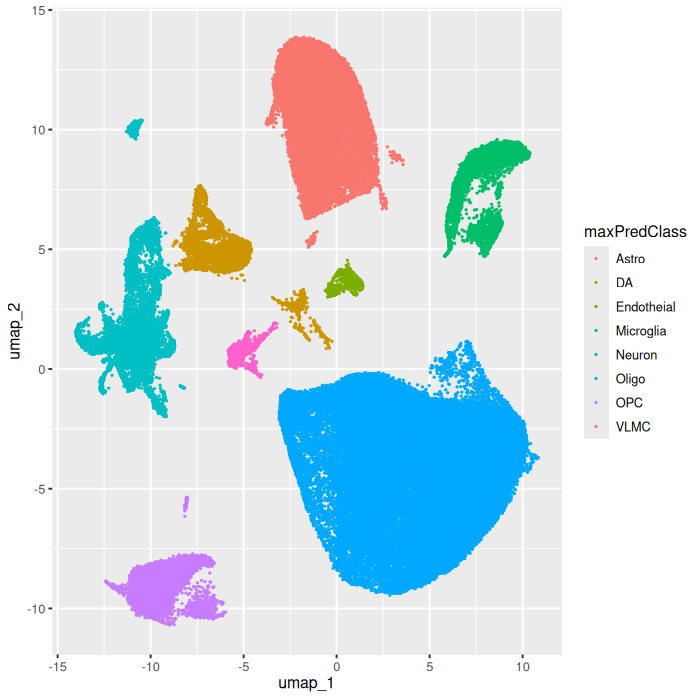

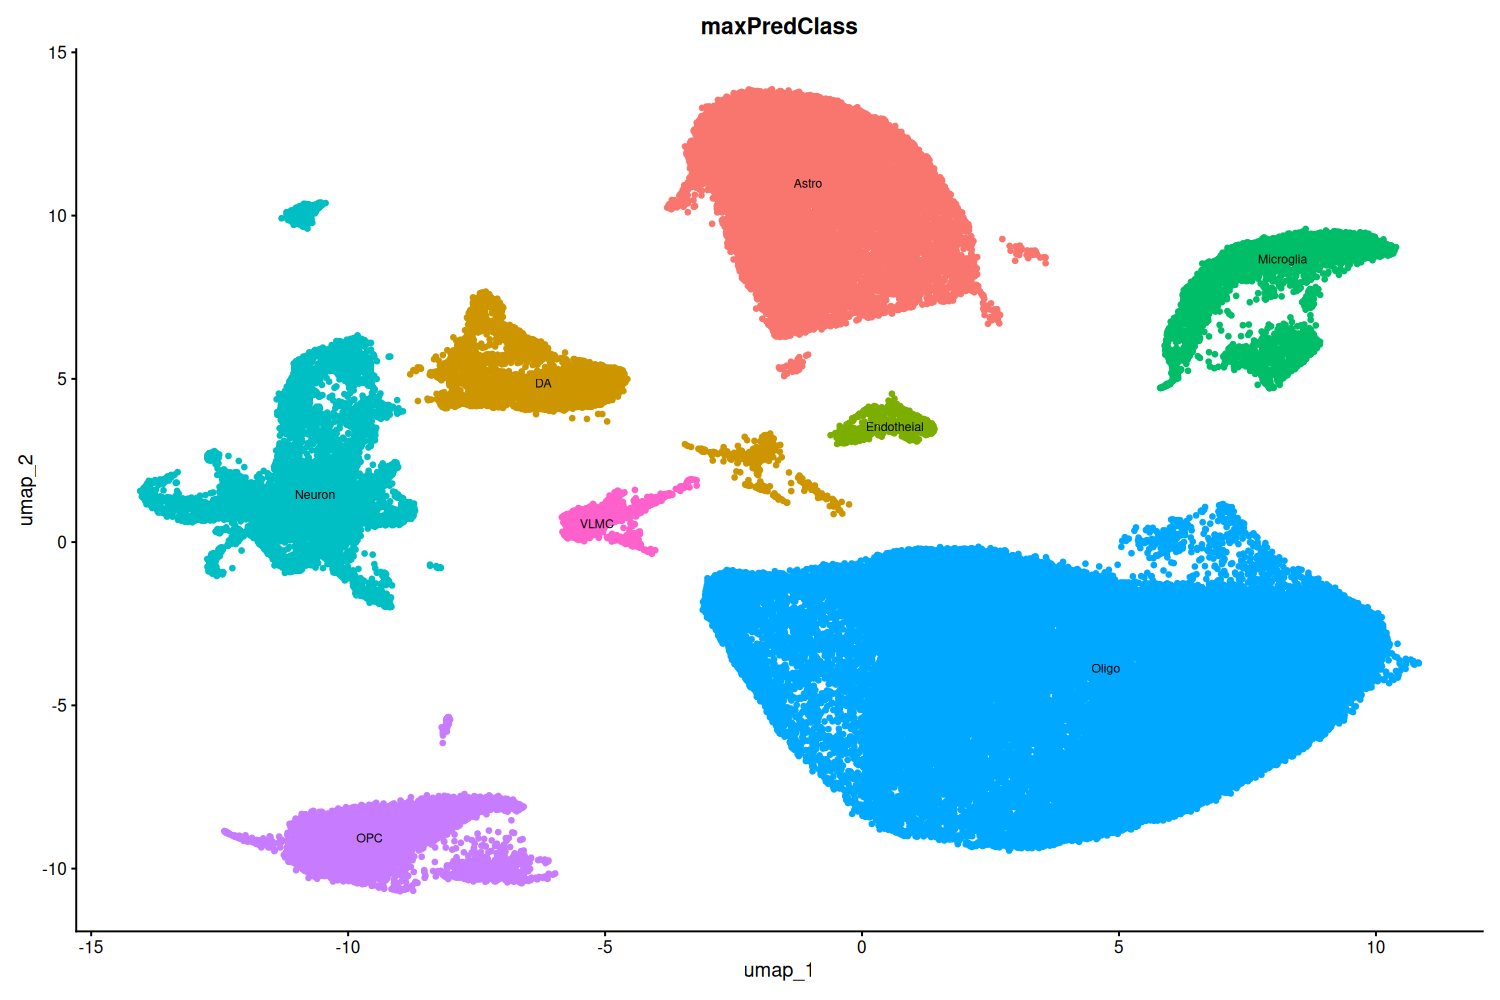

In [63]:
classFiltSeurat_filt = classFiltSeurat


umap_data <- FetchData(classFiltSeurat_filt,vars = c('umap_1','umap_2','maxPredClass'))
lapply(unique(classFiltSeurat_filt$maxPredClass), function(x){
    data <- umap_data %>% filter(maxPredClass== x)
    ### 关键参数： eps[检测范围]；minPts[当前范围内最少应包含的细胞数量]
    dbscanResult <- dbscan::dbscan(as.matrix(data[,1:2]), eps= 0.3, minPts= 10)$cluster
    return({
        rownames(data)[dbscanResult > 0]
    })
}) %>% unlist -> inlier_Cells
options(repr.plot.width = 7, repr.plot.height = 7)
umap_data[inlier_Cells,] %>% ggplot(aes(x = umap_1, y = umap_2, color = maxPredClass)) + geom_point(size = 0.01)

umap_data <- umap_data[inlier_Cells,] 
# umap_data <- umap_data[inlier_Cells,]  %>% filter(!(subclass == "VLMC|EC" & umap_1 > 4)) 

cleanUp_nc <- subset(classFiltSeurat_filt, cells = rownames(umap_data))
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)
DimPlot(cleanUp_nc, group.by = "maxPredClass",label = T, label.size =  3,pt.size = 1) & NoLegend() 

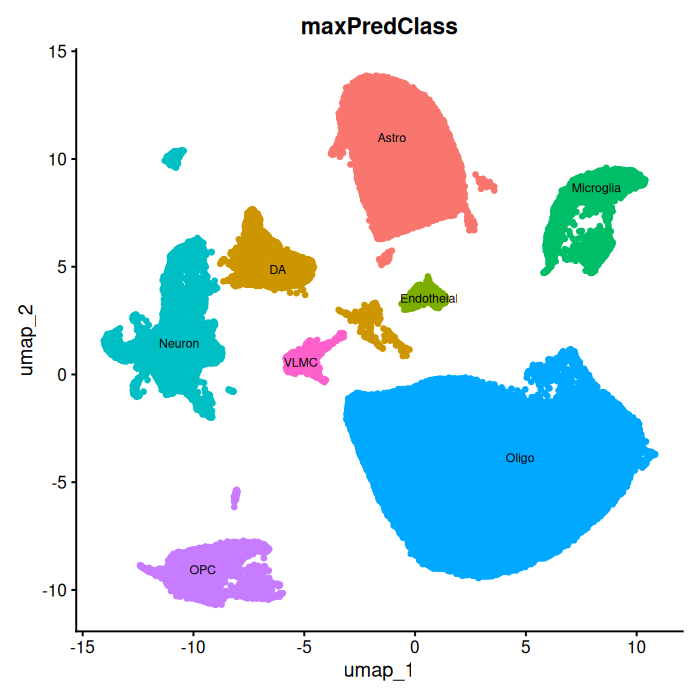

In [64]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 100)
DimPlot(cleanUp_nc, group.by = "maxPredClass",label = T, label.size =  3,pt.size = 1) & NoLegend() 

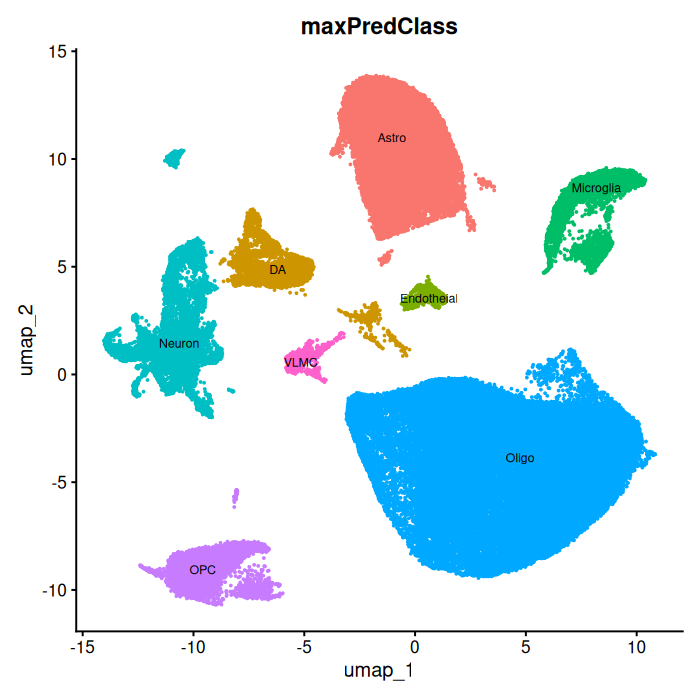

In [66]:
options(repr.plot.width = 7, repr.plot.height = 7)
DimPlot(cleanUp_nc, group.by = "maxPredClass",label = T, label.size =  3) & NoLegend() 

In [81]:
cleanUp_nc@meta.data %>% head()



,orig.ident,nCount_RNA,nFeature_RNA,Species,Animal,sample_name,Library,main structure,area,dataset,countFeatureRatio,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.7,seurat_clusters,Mouse_anno,class,maxPredClassScore,maxPredClass
,<fct>,<dbl>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<int>,<fct>,<fct>,<chr>,<chr>,<dbl>,<chr>
cDNA-250114094:CELL1_N5,SeuratProject,1349,890,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,vta_new,1.515730,0.1482580,1569,885,1,1,31 OPC-Oligo,Oligo,0.856,Oligo
cDNA-250114094:CELL2_N4,SeuratProject,1439,961,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,vta_new,1.497399,0.4169562,1585,953,2,2,30 Astro-Epen,Oligo,0.930,Oligo
cDNA-250114094:CELL3_N2,SeuratProject,14785,4744,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,vta_new,3.116568,0.0000000,2085,1540,6,6,20 MB GABA,Neuron,0.918,Neuron
cDNA-250114094:CELL5_N4,SeuratProject,1444,911,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,vta_new,1.585071,0.1385042,1586,905,0,0,31 OPC-Oligo,Oligo,0.908,Oligo
cDNA-250114094:CELL7_N5,SeuratProject,2407,1546,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,vta_new,1.556921,0.7893644,2226,1521,16,16,31 OPC-Oligo,Microglia,0.942,Microglia
cDNA-250114094:CELL8_N5,SeuratProject,3821,1922,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,vta_new,1.988033,0.0000000,2524,1772,4,4,30 Astro-Epen,Astro,0.990,Astro


In [82]:
saveRDS(cleanUp_nc, "/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/VTA_SCTseurat_harmony_rf_clean.rds")

In [83]:
cleanUp_nc

An object of class Seurat 
39808 features across 85863 samples within 2 assays 
Active assay: SCT (19451 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

In [ ]:
DotPlot(seurat,
        features = features,
        cluster.idents = FALSE) +
    RotatedAxis(45) +
    scale_color_gradient2(
        low = "#2166AC",
        mid = "white",
        high = "#B2182B",
        midpoint = 0
    )